In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('DM1_games_clean.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few columns: {df.columns.tolist()[:20]}")

Dataset shape: (21925, 42)

First few columns: ['BGGId', 'Name', 'Description', 'YearPublished', 'GameWeight', 'ComWeight', 'MinPlayers', 'MaxPlayers', 'ComAgeRec', 'LanguageEase', 'GoodPlayers', 'NumOwned', 'NumWant', 'NumWish', 'NumWeightVotes', 'ComMinPlaytime', 'ComMaxPlaytime', 'MfgAgeRec', 'NumUserRatings', 'NumAlternates']


In [2]:
# Check the data
df.head()

,BGGId,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,...,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating
0,140386,Assassin's Creed: Arena,game description publisherin assassins creed a...,2014,1.8333,2.0512,2,4,8.0,213.0,...,21926,0,0,0,0,0,0,0,0,Low
1,344114,Bag of Chips,bag chip party game face crucial choice score ...,2021,1.0000,1.2256,2,5,8.0,36.0,...,21926,0,0,0,0,0,0,0,0,Medium
2,319196,Gùgōng: Deluxe Big Box,big box contain component gugravegng deluxe ed...,2020,3.6667,3.8190,1,5,10.0,138.0,...,21926,0,0,0,0,0,0,0,0,High
3,11404,LetterFlip,publisherthe reveal game secret wordsletterfli...,2004,1.3077,1.4216,2,2,7.0,138.0,...,21926,0,0,0,0,0,0,0,0,Low
4,281020,Treasures of Cibola,rescue mayan treasure easy task ...,2019,1.5000,1.6230,2,4,10.0,7.0,...,21926,0,0,0,0,0,0,0,0,Medium


## Step 1: Find ALL Existing Binary Columns

We need to automatically detect all columns that are already binary (0/1) including:
- Cat:* (Categories)
- Any other binary features

In [3]:
# Automatically detect binary columns (columns with only 0 and 1 values)
binary_cols = []

for col in df.columns:
    # Check if column has only 0 and 1 values (and is numeric)
    if df[col].dtype in ['int64', 'float64']:
        unique_vals = df[col].unique()
        if set(unique_vals).issubset({0, 1, 0.0, 1.0}):
            binary_cols.append(col)

print(f"Found {len(binary_cols)} binary columns!\n")
print("Binary columns by prefix:")

# Group by prefix for better visualization
prefixes = {}
for col in binary_cols:
    prefix = col.split(':')[0] if ':' in col else 'Other'
    if prefix not in prefixes:
        prefixes[prefix] = []
    prefixes[prefix].append(col)

for prefix, cols in sorted(prefixes.items()):
    print(f"\n{prefix}: {len(cols)} columns")
    print(f"  Examples: {cols[:5]}")

Found 10 binary columns!

Binary columns by prefix:

Cat: 8 columns
  Examples: ['Cat:Thematic', 'Cat:Strategy', 'Cat:War', 'Cat:Family', 'Cat:CGS']

Other: 2 columns
  Examples: ['IsReimplementation', 'Kickstarted']


## Step 2: Create Engineered Features (Bins)

Now we'll create binary features from continuous variables.

In [4]:
# Create a copy for pattern mining
df_patterns = df.copy()

# 1. GameWeight bins
df_patterns['Weight:Light'] = (df_patterns['GameWeight'] < 2).astype(int)
df_patterns['Weight:Medium'] = ((df_patterns['GameWeight'] >= 2) & (df_patterns['GameWeight'] < 3.5)).astype(int)
df_patterns['Weight:Heavy'] = (df_patterns['GameWeight'] >= 3.5).astype(int)

print("GameWeight distribution:")
print(f"Light: {df_patterns['Weight:Light'].sum()}")
print(f"Medium: {df_patterns['Weight:Medium'].sum()}")
print(f"Heavy: {df_patterns['Weight:Heavy'].sum()}")

GameWeight distribution:
Light: 11005
Medium: 9727
Heavy: 1193


In [5]:
# 2. Rating bins convert categorical labels to binary columns
df_patterns['Rating:Low'] = (df_patterns['Rating'] == 'Low').astype(int)
df_patterns['Rating:Medium'] = (df_patterns['Rating'] == 'Medium').astype(int)
df_patterns['Rating:High'] = (df_patterns['Rating'] == 'High').astype(int)

print("Rating distribution (from categorical):")
print(f"Low: {df_patterns['Rating:Low'].sum()}")
print(f"Medium: {df_patterns['Rating:Medium'].sum()}")
print(f"High: {df_patterns['Rating:High'].sum()}")

Rating distribution (from categorical):
Low: 7245
Medium: 9644
High: 5036


In [6]:
# 3. Playtime bins
df_patterns['Time:Quick'] = (df_patterns['ComMinPlaytime'] < 30).astype(int)
df_patterns['Time:Medium'] = ((df_patterns['ComMinPlaytime'] >= 30) &
                               (df_patterns['ComMinPlaytime'] < 90)).astype(int)
df_patterns['Time:Long'] = ((df_patterns['ComMinPlaytime'] >= 90) &
                             (df_patterns['ComMinPlaytime'] < 180)).astype(int)
df_patterns['Time:Epic'] = (df_patterns['ComMinPlaytime'] >= 180).astype(int)

print("Playtime distribution:")
print(f"Quick (<30min): {df_patterns['Time:Quick'].sum()}")
print(f"Medium (30-90min): {df_patterns['Time:Medium'].sum()}")
print(f"Long (90-180min): {df_patterns['Time:Long'].sum()}")
print(f"Epic (>180min): {df_patterns['Time:Epic'].sum()}")

Playtime distribution:
Quick (<30min): 7243
Medium (30-90min): 10408
Long (90-180min): 2638
Epic (>180min): 1636


In [7]:
# 4. Popularity bins (based on NumOwned, using tertiles)
pop_tertiles = df_patterns['NumOwned'].quantile([0.33, 0.67])
print(f"Popularity tertiles:\n{pop_tertiles}\n")

df_patterns['Pop:Low'] = (df_patterns['NumOwned'] <= pop_tertiles[0.33]).astype(int)
df_patterns['Pop:Medium'] = ((df_patterns['NumOwned'] > pop_tertiles[0.33]) &
                              (df_patterns['NumOwned'] <= pop_tertiles[0.67])).astype(int)
df_patterns['Pop:High'] = (df_patterns['NumOwned'] > pop_tertiles[0.67]).astype(int)

print("Popularity distribution:")
print(f"Low: {df_patterns['Pop:Low'].sum()}")
print(f"Medium: {df_patterns['Pop:Medium'].sum()}")
print(f"High: {df_patterns['Pop:High'].sum()}")

Popularity tertiles:
0.33    192.00
0.67    615.08
Name: NumOwned, dtype: float64

Popularity distribution:
Low: 7238
Medium: 7452
High: 7235


In [8]:
# 5. Era bins
df_patterns['Era:Vintage'] = (df_patterns['YearPublished'] < 2000).astype(int)
df_patterns['Era:Classic'] = ((df_patterns['YearPublished'] >= 2000) &
                               (df_patterns['YearPublished'] < 2010)).astype(int)
df_patterns['Era:Modern'] = ((df_patterns['YearPublished'] >= 2010) &
                              (df_patterns['YearPublished'] < 2020)).astype(int)
df_patterns['Era:Recent'] = (df_patterns['YearPublished'] >= 2020).astype(int)

print("Era distribution:")
print(f"Vintage (<2000): {df_patterns['Era:Vintage'].sum()}")
print(f"Classic (2000-2010): {df_patterns['Era:Classic'].sum()}")
print(f"Modern (2010-2020): {df_patterns['Era:Modern'].sum()}")
print(f"Recent (>=2020): {df_patterns['Era:Recent'].sum()}")

Era distribution:
Vintage (<2000): 4711
Classic (2000-2010): 4713
Modern (2010-2020): 10914
Recent (>=2020): 1587


## Step 3: Combine ALL Binary Features

Now we combine:
- All existing binary columns (Cat, Dom, Mecha, SubD, etc.)
- Our newly engineered features

In [9]:
# List of engineered features we just created
engineered_features = [
    'Weight:Light', 'Weight:Medium', 'Weight:Heavy',
    'Rating:Low', 'Rating:Medium', 'Rating:High',
    'Time:Quick', 'Time:Medium', 'Time:Long', 'Time:Epic',
    'Pop:Low', 'Pop:Medium', 'Pop:High',
    'Era:Vintage', 'Era:Classic', 'Era:Modern', 'Era:Recent'
]

# Combine existing binary columns + engineered features
all_pattern_features = binary_cols + engineered_features

print(f"Total features for pattern mining: {len(all_pattern_features)}")
print(f"  - Existing binary columns: {len(binary_cols)}")
print(f"  - Engineered features: {len(engineered_features)}")
print(f"\nFeature breakdown by prefix:")

# Show breakdown
all_prefixes = {}
for col in all_pattern_features:
    prefix = col.split(':')[0] if ':' in col else 'Other'
    if prefix not in all_prefixes:
        all_prefixes[prefix] = 0
    all_prefixes[prefix] += 1

for prefix, count in sorted(all_prefixes.items(), key=lambda x: x[1], reverse=True):
    print(f"  {prefix}: {count}")

Total features for pattern mining: 27
  - Existing binary columns: 10
  - Engineered features: 17

Feature breakdown by prefix:
  Cat: 8
  Time: 4
  Era: 4
  Weight: 3
  Rating: 3
  Pop: 3
  Other: 2


## Step 4: Create Transaction Format

Convert binary features into transaction format where each game is a list of items (features = 1).

In [10]:
# Create the mining dataset with all features
df_mining = df_patterns[all_pattern_features].copy()

# Check for missing values
print("Missing values:")
missing = df_mining.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("No missing values!")

print(f"\nFinal dataset shape: {df_mining.shape}")

Missing values:
No missing values!

Final dataset shape: (21925, 27)


In [11]:
# Convert to transaction format
# Each row becomes a list of feature names where value = 1
transactions = []
for idx, row in df_mining.iterrows():
    transaction = [col for col in df_mining.columns if row[col] == 1]
    transactions.append(transaction)

print(f"Total transactions (games): {len(transactions)}")
print(f"\nFirst 3 transactions:")
for i, trans in enumerate(transactions[:3]):
    print(f"\nGame {i+1} ({len(trans)} items):\n  {trans}")

Total transactions (games): 21925

First 3 transactions:

Game 1 (5 items):
  ['Weight:Light', 'Rating:Low', 'Time:Medium', 'Pop:Medium', 'Era:Modern']

Game 2 (5 items):
  ['Weight:Light', 'Rating:Medium', 'Time:Quick', 'Pop:Low', 'Era:Recent']

Game 3 (5 items):
  ['Weight:Heavy', 'Rating:High', 'Time:Medium', 'Pop:High', 'Era:Recent']


Transaction Statistics:
Average items per game: 5.83
Min items: 5
Max items: 10
Median items: 6.00


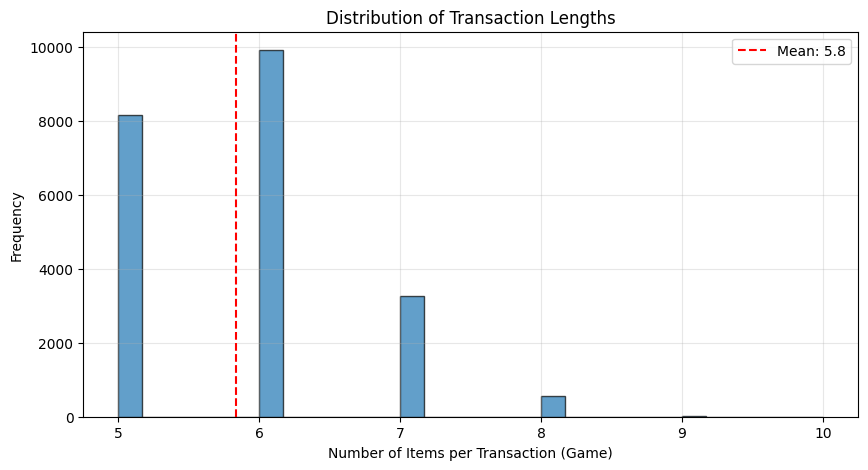

In [12]:
# Transaction statistics
transaction_lengths = [len(t) for t in transactions]

print("Transaction Statistics:")
print(f"Average items per game: {np.mean(transaction_lengths):.2f}")
print(f"Min items: {np.min(transaction_lengths)}")
print(f"Max items: {np.max(transaction_lengths)}")
print(f"Median items: {np.median(transaction_lengths):.2f}")

# Visualize
plt.figure(figsize=(10, 5))
plt.hist(transaction_lengths, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(np.mean(transaction_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(transaction_lengths):.1f}')
plt.xlabel('Number of Items per Transaction (Game)')
plt.ylabel('Frequency')
plt.title('Distribution of Transaction Lengths')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Step 5: Prepare Data for Apriori Algorithm

We need to convert transactions into a format that mlxtend's Apriori can use.

In [13]:
# Install mlxtend if needed
try:
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    print("mlxtend already installed!")
except ImportError:
    print("Installing mlxtend...")
    !pip install mlxtend
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    print("mlxtend installed successfully!")

mlxtend already installed!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [14]:
# Use TransactionEncoder to convert transactions to one-hot encoded DataFrame
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Encoded dataset shape: {df_encoded.shape}")
print(f"This is ready for Apriori!\n")
print("Sample of encoded data:")
df_encoded.head()

Encoded dataset shape: (21925, 27)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


This is ready for Apriori!

Sample of encoded data:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Cat:Abstract,Cat:CGS,Cat:Childrens,Cat:Family,Cat:Party,Cat:Strategy,Cat:Thematic,Cat:War,Era:Classic,Era:Modern,...,Rating:High,Rating:Low,Rating:Medium,Time:Epic,Time:Long,Time:Medium,Time:Quick,Weight:Heavy,Weight:Light,Weight:Medium
0,False,False,False,False,False,False,False,False,False,True,...,False,True,False,False,False,True,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,True,False,True,False,False
3,False,False,False,False,False,False,False,False,True,False,...,False,True,False,False,False,False,True,False,True,False
4,False,False,False,False,False,False,False,False,False,True,...,False,False,True,False,False,False,True,False,True,False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [15]:
# Check support for some items (how often they appear)
item_support = df_encoded.mean().sort_values(ascending=False)

print("Top 20 most frequent items:")
print(item_support.head(20))

print("\nBottom 20 least frequent items:")
print(item_support.tail(20))

Top 20 most frequent items:
Weight:Light          0.501938
Era:Modern            0.497788
Time:Medium           0.474709
Weight:Medium         0.443649
Rating:Medium         0.439863
Pop:Medium            0.339886
Rating:Low            0.330445
Time:Quick            0.330353
Pop:Low               0.330125
Pop:High              0.329989
Rating:High           0.229692
Era:Classic           0.214960
Era:Vintage           0.214869
Cat:War               0.161003
Kickstarted           0.153341
Time:Long             0.120319
IsReimplementation    0.116762
Cat:Strategy          0.105770
Cat:Family            0.105633
Time:Epic             0.074618
dtype: float64

Bottom 20 least frequent items:
Time:Quick            0.330353
Pop:Low               0.330125
Pop:High              0.329989
Rating:High           0.229692
Era:Classic           0.214960
Era:Vintage           0.214869
Cat:War               0.161003
Kickstarted           0.153341
Time:Long             0.120319
IsReimplementation    0.1

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

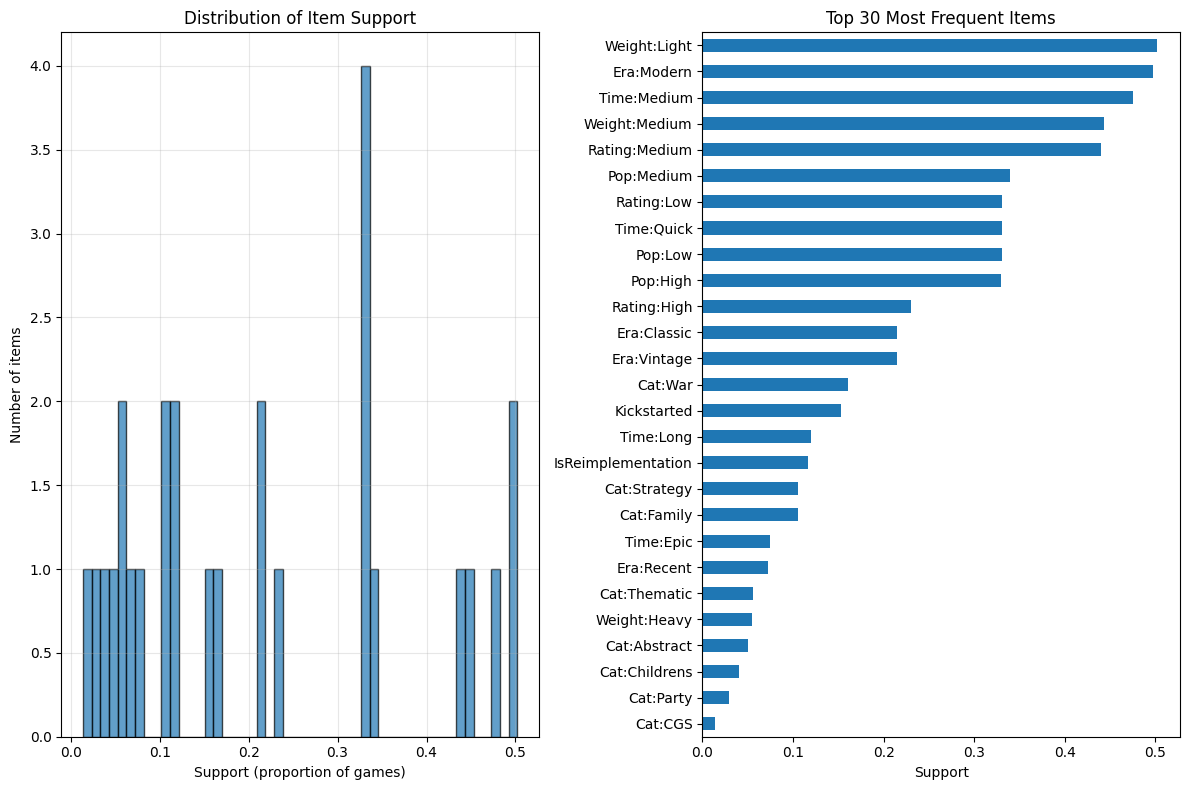

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [16]:
# Visualize item support distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(item_support, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Support (proportion of games)')
plt.ylabel('Number of items')
plt.title('Distribution of Item Support')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
item_support.head(30).plot(kind='barh', figsize=(12, 8))
plt.xlabel('Support')
plt.title('Top 30 Most Frequent Items')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [17]:
# Save everything for Step 2
df_mining.to_csv('boardgames_pattern_mining.csv', index=False)
print("Saved: boardgames_pattern_mining.csv")

df_encoded.to_csv('boardgames_encoded.csv', index=False)
print("Saved: boardgames_encoded.csv")

import pickle
with open('transactions.pkl', 'wb') as f:
    pickle.dump(transactions, f)
print("Saved: transactions.pkl")

with open('all_pattern_features.pkl', 'wb') as f:
    pickle.dump(all_pattern_features, f)
print("Saved: all_pattern_features.pkl")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Saved: boardgames_pattern_mining.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Saved: boardgames_encoded.csv
Saved: transactions.pkl
Saved: all_pattern_features.pkl


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# Pattern Mining Frequent Patterns & Association Rules

# Apriori Algorithm with Analysis

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Load prepared Data

In [19]:
# Load the encoded dataframe (ready for Apriori)
df_encoded = pd.read_csv('boardgames_encoded.csv')

print(f"Loaded encoded dataset: {df_encoded.shape}")
print(f"Ready for Apriori!\n")

# Load transactions for reference
with open('transactions.pkl', 'rb') as f:
    transactions = pickle.load(f)

print(f"Loaded {len(transactions)} transactions")
print(f"Average items per transaction: {np.mean([len(t) for t in transactions]):.2f}")

Loaded encoded dataset: (21925, 27)
Ready for Apriori!

Loaded 21925 transactions
Average items per transaction: 5.83


In [20]:
# Quick check of the data
df_encoded.head()

,Cat:Abstract,Cat:CGS,Cat:Childrens,Cat:Family,Cat:Party,Cat:Strategy,Cat:Thematic,Cat:War,Era:Classic,Era:Modern,...,Rating:High,Rating:Low,Rating:Medium,Time:Epic,Time:Long,Time:Medium,Time:Quick,Weight:Heavy,Weight:Light,Weight:Medium
0,False,False,False,False,False,False,False,False,False,True,...,False,True,False,False,False,True,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,True,False,True,False,False
3,False,False,False,False,False,False,False,False,True,False,...,False,True,False,False,False,False,True,False,True,False
4,False,False,False,False,False,False,False,False,False,True,...,False,False,True,False,False,False,True,False,True,False


## Part 1: Frequent Pattern Extraction

### Testing Different Support Values

We'll run Apriori with multiple minimum support thresholds to see how the number of patterns changes.

In [21]:
# Define support values to test
support_values = [0.01, 0.03, 0.05, 0.1, 0.15, 0.2]

print("Testing support values:", support_values)
print("\nRunning Apriori algorithm...\n")

# Store results
frequent_itemsets_dict = {}
pattern_counts = []

for min_sup in support_values:
    # Run Apriori
    frequent_itemsets = apriori(df_encoded, min_support=min_sup, use_colnames=True)

    # Store results
    frequent_itemsets_dict[min_sup] = frequent_itemsets
    num_patterns = len(frequent_itemsets)
    pattern_counts.append(num_patterns)

    print(f"min_support = {min_sup:4.2f} → {num_patterns:5d} frequent itemsets")

print("\n✓ Frequent pattern extraction complete!")

Testing support values: [0.01, 0.03, 0.05, 0.1, 0.15, 0.2]

Running Apriori algorithm...

min_support = 0.01 →  1226 frequent itemsets
min_support = 0.03 →   397 frequent itemsets
min_support = 0.05 →   207 frequent itemsets
min_support = 0.10 →    78 frequent itemsets
min_support = 0.15 →    41 frequent itemsets
min_support = 0.20 →    24 frequent itemsets

✓ Frequent pattern extraction complete!


### Analysis 1: Support vs Number of Patterns

In [22]:
# Create summary table
support_analysis = pd.DataFrame({
    'Min Support': support_values,
    'Number of Patterns': pattern_counts
})

print("\n" + "="*50)
print("SUPPORT vs NUMBER OF PATTERNS")
print("="*50)
print(support_analysis.to_string(index=False))
print("="*50)


SUPPORT vs NUMBER OF PATTERNS
 Min Support  Number of Patterns
        0.01                1226
        0.03                 397
        0.05                 207
        0.10                  78
        0.15                  41
        0.20                  24


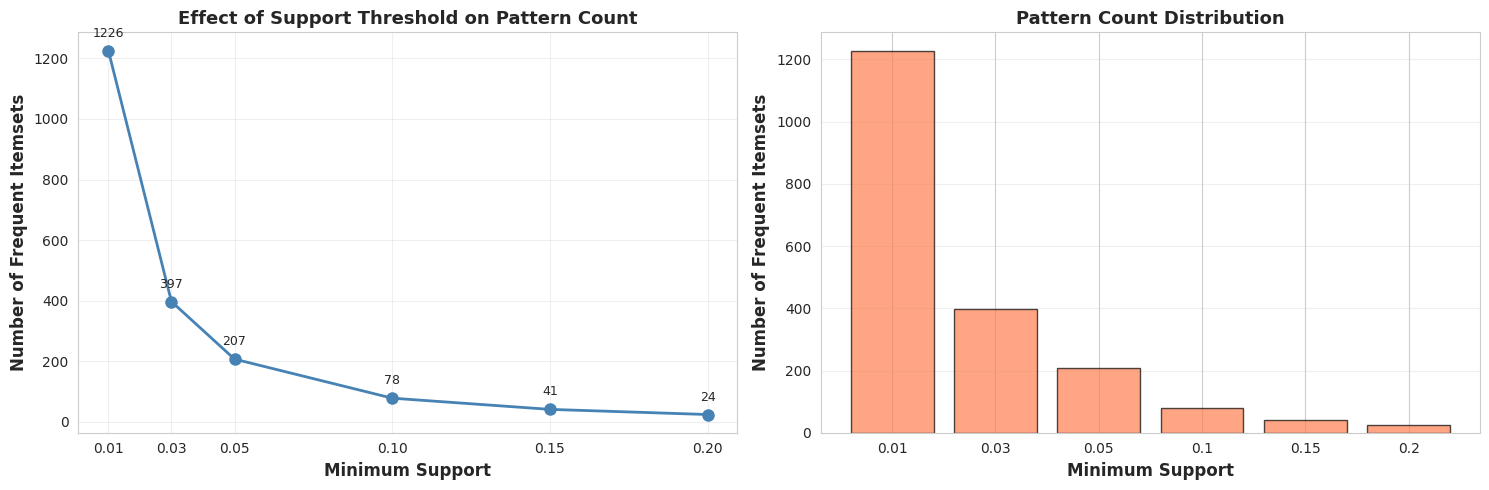


📊 Key Observation:
   As minimum support increases from 0.01 to 0.2,
   the number of patterns decreases from 1226 to 24.
   This is expected: higher support = stricter threshold = fewer patterns.


In [23]:
# Visualize: Support threshold vs Number of itemsets
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Line plot
axes[0].plot(support_values, pattern_counts, marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0].set_xlabel('Minimum Support', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Frequent Itemsets', fontsize=12, fontweight='bold')
axes[0].set_title('Effect of Support Threshold on Pattern Count', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(support_values)

# Add value labels
for x, y in zip(support_values, pattern_counts):
    axes[0].annotate(f'{y}', (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

# Bar plot
axes[1].bar(range(len(support_values)), pattern_counts, color='coral', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Minimum Support', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Frequent Itemsets', fontsize=12, fontweight='bold')
axes[1].set_title('Pattern Count Distribution', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(len(support_values)))
axes[1].set_xticklabels(support_values)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n📊 Key Observation:")
print(f"   As minimum support increases from {support_values[0]} to {support_values[-1]},")
print(f"   the number of patterns decreases from {pattern_counts[0]} to {pattern_counts[-1]}.")
print(f"   This is expected: higher support = stricter threshold = fewer patterns.")

### Analysis 2: Top Frequent Patterns

Let's examine the most frequent itemsets at different support levels.

In [24]:
# Choose a good support value for detailed analysis (e.g., 0.05)
chosen_support = 0.05
frequent_itemsets = frequent_itemsets_dict[chosen_support].copy()

# Add itemset length
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

print(f"\n" + "="*70)
print(f"TOP 10 FREQUENT ITEMSETS (min_support = {chosen_support})")
print("="*70)

top_10 = frequent_itemsets.nlargest(10, 'support')
for idx, row in top_10.iterrows():
    items = ', '.join(sorted(row['itemsets']))
    print(f"{row['support']:.4f} | {items}")

print("="*70)


TOP 10 FREQUENT ITEMSETS (min_support = 0.05)
0.5019 | Weight:Light
0.4978 | Era:Modern
0.4747 | Time:Medium
0.4436 | Weight:Medium
0.4399 | Rating:Medium
0.3399 | Pop:Medium
0.3304 | Rating:Low
0.3304 | Time:Quick
0.3301 | Pop:Low
0.3300 | Pop:High



Itemset Length Distribution (min_support = 0.05):
length
1    24
2    93
3    81
4     9
Name: count, dtype: int64


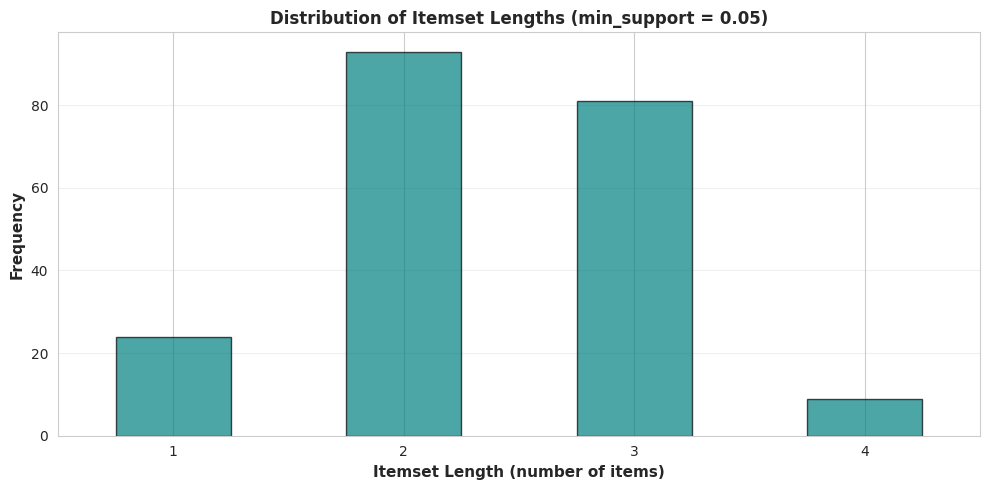

In [25]:
# Analyze itemset length distribution
length_dist = frequent_itemsets['length'].value_counts().sort_index()

print(f"\nItemset Length Distribution (min_support = {chosen_support}):")
print(length_dist)

# Visualize
plt.figure(figsize=(10, 5))
length_dist.plot(kind='bar', color='teal', alpha=0.7, edgecolor='black')
plt.xlabel('Itemset Length (number of items)', fontsize=11, fontweight='bold')
plt.ylabel('Frequency', fontsize=11, fontweight='bold')
plt.title(f'Distribution of Itemset Lengths (min_support = {chosen_support})', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Qualitative Analysis of Patterns

Let's interpret some interesting patterns we found.

In [26]:
# Look at some interesting 3-itemsets
print("\n" + "="*70)
print("INTERESTING 3-ITEM PATTERNS")
print("="*70)

itemsets_3 = frequent_itemsets[frequent_itemsets['length'] == 3].nlargest(10, 'support')

if len(itemsets_3) > 0:
    for idx, row in itemsets_3.iterrows():
        items = ', '.join(sorted(row['itemsets']))
        print(f"{row['support']:.4f} | {items}")
else:
    print("No 3-itemsets found at this support level.")

print("="*70)


INTERESTING 3-ITEM PATTERNS
0.1582 | Era:Modern, Time:Quick, Weight:Light
0.1444 | Era:Modern, Time:Medium, Weight:Medium
0.1330 | Era:Modern, Rating:Medium, Weight:Light
0.1232 | Rating:Low, Time:Quick, Weight:Light
0.1222 | Era:Modern, Rating:Medium, Time:Medium
0.1173 | Rating:Medium, Time:Quick, Weight:Light
0.1136 | Rating:Medium, Time:Medium, Weight:Medium
0.1121 | Pop:Low, Rating:Low, Weight:Light
0.1119 | Rating:Low, Time:Medium, Weight:Light
0.1118 | Pop:Low, Time:Quick, Weight:Light


##Association Rules Extraction

### Testing Different Confidence Values

Now we'll generate association rules from the frequent itemsets.

In [27]:
# Use frequent itemsets from chosen support level
print(f"Generating association rules from itemsets (min_support = {chosen_support})...\n")

# Define confidence values to test
confidence_values = [0.5, 0.6, 0.7, 0.8, 0.9]

# Store results
rules_dict = {}
rule_counts = []

for min_conf in confidence_values:
    # Generate rules
    try:
        rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_conf)
        rules_dict[min_conf] = rules
        num_rules = len(rules)
        rule_counts.append(num_rules)
        print(f"min_confidence = {min_conf:.1f} → {num_rules:5d} association rules")
    except:
        print(f"min_confidence = {min_conf:.1f} → No rules generated")
        rule_counts.append(0)

print("\n✓ Association rule extraction complete!")

Generating association rules from itemsets (min_support = 0.05)...

min_confidence = 0.5 →   177 association rules
min_confidence = 0.6 →    86 association rules
min_confidence = 0.7 →    46 association rules
min_confidence = 0.8 →    12 association rules
min_confidence = 0.9 →     1 association rules

✓ Association rule extraction complete!


### Analysis 3: Confidence vs Number of Rules

In [28]:
# Create summary table
confidence_analysis = pd.DataFrame({
    'Min Confidence': confidence_values,
    'Number of Rules': rule_counts
})

print("\n" + "="*50)
print("CONFIDENCE vs NUMBER OF RULES")
print("="*50)
print(confidence_analysis.to_string(index=False))
print("="*50)


CONFIDENCE vs NUMBER OF RULES
 Min Confidence  Number of Rules
            0.5              177
            0.6               86
            0.7               46
            0.8               12
            0.9                1


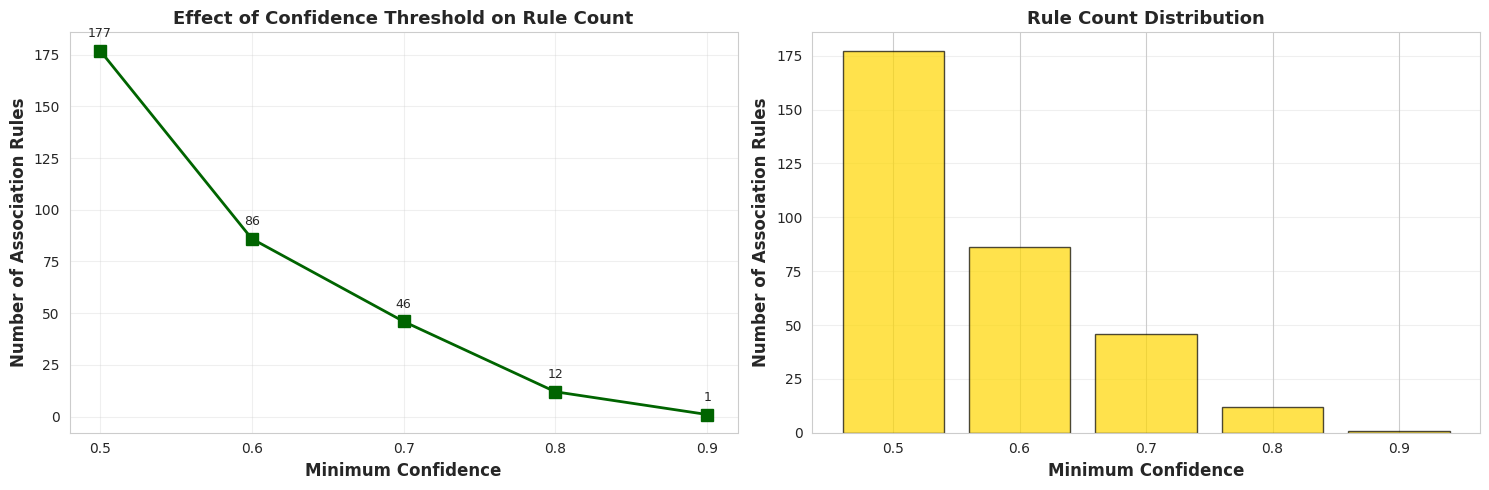


📊 Key Observation:
   As minimum confidence increases from 0.5 to 0.9,
   the number of rules decreases from 177 to 1.
   Higher confidence means stricter rules with stronger implications.


In [29]:
# Visualize: Confidence threshold vs Number of rules
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Line plot
axes[0].plot(confidence_values, rule_counts, marker='s', linewidth=2, markersize=8, color='darkgreen')
axes[0].set_xlabel('Minimum Confidence', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Association Rules', fontsize=12, fontweight='bold')
axes[0].set_title('Effect of Confidence Threshold on Rule Count', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(confidence_values)

# Add value labels
for x, y in zip(confidence_values, rule_counts):
    axes[0].annotate(f'{y}', (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

# Bar plot
axes[1].bar(range(len(confidence_values)), rule_counts, color='gold', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Minimum Confidence', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Association Rules', fontsize=12, fontweight='bold')
axes[1].set_title('Rule Count Distribution', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(len(confidence_values)))
axes[1].set_xticklabels(confidence_values)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n📊 Key Observation:")
print(f"   As minimum confidence increases from {confidence_values[0]} to {confidence_values[-1]},")
print(f"   the number of rules decreases from {rule_counts[0]} to {rule_counts[-1]}.")
print(f"   Higher confidence means stricter rules with stronger implications.")

### Analysis 4: Rules Distribution (Confidence & Lift)

Let's analyze the distribution of confidence and lift values for our rules.

In [30]:
# Choose a good confidence value for detailed analysis
chosen_confidence = 0.6
rules = rules_dict[chosen_confidence].copy()

print(f"\nAnalyzing {len(rules)} rules with min_confidence = {chosen_confidence}")
print(f"\nRule Statistics:")
print(f"  Confidence: mean={rules['confidence'].mean():.3f}, std={rules['confidence'].std():.3f}")
print(f"  Lift:       mean={rules['lift'].mean():.3f}, std={rules['lift'].std():.3f}")
print(f"  Support:    mean={rules['support'].mean():.3f}, std={rules['support'].std():.3f}")


Analyzing 86 rules with min_confidence = 0.6

Rule Statistics:
  Confidence: mean=0.720, std=0.080
  Lift:       mean=1.666, std=0.527
  Support:    mean=0.085, std=0.040


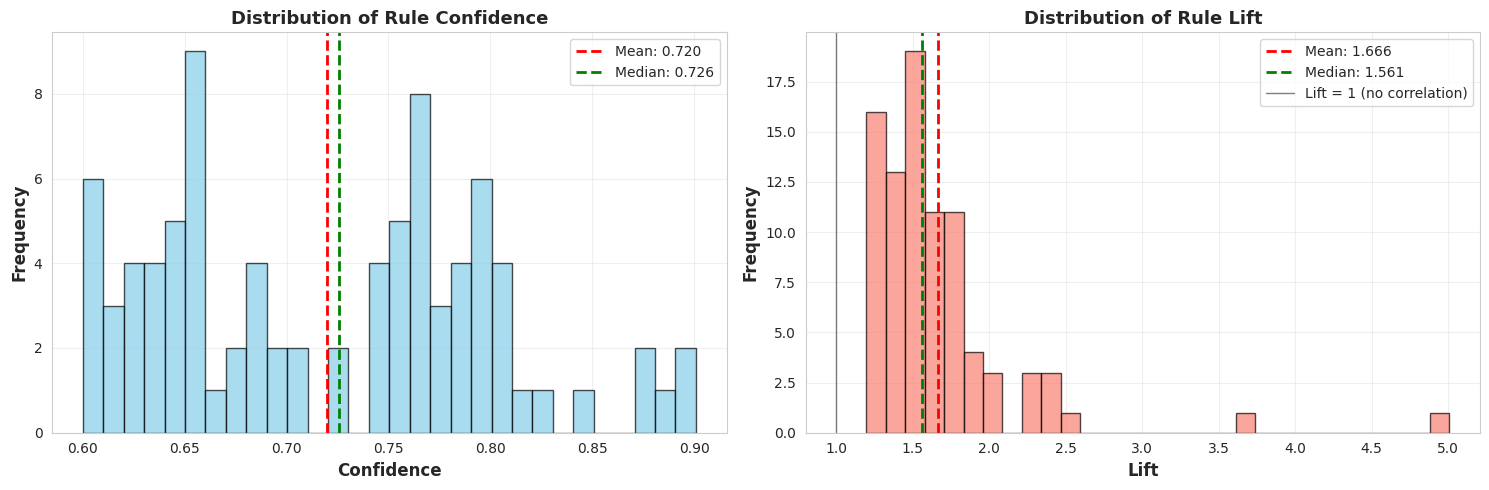


📊 Interpretation:
   • Confidence: Measures how often the consequent appears when the antecedent is present
   • Lift > 1: Positive correlation (consequent is more likely when antecedent is present)
   • Lift = 1: No correlation (independent events)
   • Lift < 1: Negative correlation (consequent is less likely when antecedent is present)


In [31]:
# Histogram of Confidence
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Confidence histogram
axes[0].hist(rules['confidence'], bins=30, color='skyblue', alpha=0.7, edgecolor='black')
axes[0].axvline(rules['confidence'].mean(), color='red', linestyle='--', linewidth=2,
                label=f"Mean: {rules['confidence'].mean():.3f}")
axes[0].axvline(rules['confidence'].median(), color='green', linestyle='--', linewidth=2,
                label=f"Median: {rules['confidence'].median():.3f}")
axes[0].set_xlabel('Confidence', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('Distribution of Rule Confidence', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Lift histogram
axes[1].hist(rules['lift'], bins=30, color='salmon', alpha=0.7, edgecolor='black')
axes[1].axvline(rules['lift'].mean(), color='red', linestyle='--', linewidth=2,
                label=f"Mean: {rules['lift'].mean():.3f}")
axes[1].axvline(rules['lift'].median(), color='green', linestyle='--', linewidth=2,
                label=f"Median: {rules['lift'].median():.3f}")
axes[1].axvline(1.0, color='black', linestyle='-', linewidth=1, alpha=0.5, label='Lift = 1 (no correlation)')
axes[1].set_xlabel('Lift', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title('Distribution of Rule Lift', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("   • Confidence: Measures how often the consequent appears when the antecedent is present")
print("   • Lift > 1: Positive correlation (consequent is more likely when antecedent is present)")
print("   • Lift = 1: No correlation (independent events)")
print("   • Lift < 1: Negative correlation (consequent is less likely when antecedent is present)")

### Analysis 5: Top Rules by Lift

Let's examine the strongest association rules (highest lift values).

In [32]:
# Top rules by lift
print("\n" + "="*100)
print("TOP 20 ASSOCIATION RULES BY LIFT")
print("="*100)
print(f"{'Antecedents':35s} => {'Consequents':20s} | Conf  | Lift  | Supp")
print("-"*100)

top_rules = rules.nlargest(20, 'lift')

for idx, row in top_rules.iterrows():
    antecedents = ', '.join(sorted(row['antecedents']))
    consequents = ', '.join(sorted(row['consequents']))

    # Truncate if too long
    if len(antecedents) > 33:
        antecedents = antecedents[:30] + '...'
    if len(consequents) > 18:
        consequents = consequents[:15] + '...'

    print(f"{antecedents:35s} => {consequents:20s} | {row['confidence']:.3f} | {row['lift']:.3f} | {row['support']:.3f}")

print("="*100)


TOP 20 ASSOCIATION RULES BY LIFT
Antecedents                         => Consequents          | Conf  | Lift  | Supp
----------------------------------------------------------------------------------------------------
Time:Epic                           => Cat:War              | 0.806 | 5.008 | 0.060
Cat:Strategy                        => Pop:High, Weigh...   | 0.602 | 3.720 | 0.064
Cat:Strategy, Time:Medium           => Pop:High             | 0.822 | 2.491 | 0.055
Cat:Strategy, Weight:Medium         => Pop:High             | 0.801 | 2.429 | 0.064
Cat:Strategy                        => Pop:High             | 0.794 | 2.406 | 0.084
Cat:Family, Time:Medium             => Pop:High             | 0.780 | 2.364 | 0.052
Cat:Family                          => Pop:High             | 0.770 | 2.333 | 0.081
Cat:Family, Weight:Light            => Pop:High             | 0.762 | 2.309 | 0.061
Era:Vintage, Weight:Light           => Rating:Low           | 0.741 | 2.243 | 0.074
Era:Modern, Pop:Low, Weigh

In [33]:
# Top rules by confidence
print("\n" + "="*100)
print("TOP 20 ASSOCIATION RULES BY CONFIDENCE")
print("="*100)
print(f"{'Antecedents':35s} => {'Consequents':20s} | Conf  | Lift  | Supp")
print("-"*100)

top_conf_rules = rules.nlargest(20, 'confidence')

for idx, row in top_conf_rules.iterrows():
    antecedents = ', '.join(sorted(row['antecedents']))
    consequents = ', '.join(sorted(row['consequents']))

    # Truncate if too long
    if len(antecedents) > 33:
        antecedents = antecedents[:30] + '...'
    if len(consequents) > 18:
        consequents = consequents[:15] + '...'

    print(f"{antecedents:35s} => {consequents:20s} | {row['confidence']:.3f} | {row['lift']:.3f} | {row['support']:.3f}")

print("="*100)


TOP 20 ASSOCIATION RULES BY CONFIDENCE
Antecedents                         => Consequents          | Conf  | Lift  | Supp
----------------------------------------------------------------------------------------------------
Era:Modern, Rating:Low, Time:Q...   => Weight:Light         | 0.901 | 1.795 | 0.062
Rating:Low, Time:Quick              => Weight:Light         | 0.899 | 1.791 | 0.123
Kickstarted, Rating:Medium          => Era:Modern           | 0.885 | 1.777 | 0.061
Pop:Low, Rating:Low, Time:Quick     => Weight:Light         | 0.874 | 1.742 | 0.062
Era:Classic, Time:Quick             => Weight:Light         | 0.872 | 1.738 | 0.053
Pop:High, Time:Quick                => Weight:Light         | 0.849 | 1.691 | 0.067
Cat:Strategy, Time:Medium           => Pop:High             | 0.822 | 2.491 | 0.055
Cat:Strategy, Time:Medium           => Weight:Medium        | 0.816 | 1.839 | 0.054
Time:Epic                           => Cat:War              | 0.806 | 5.008 | 0.060
Era:Classic, Rating:

### Scatter Plot: Confidence vs Lift

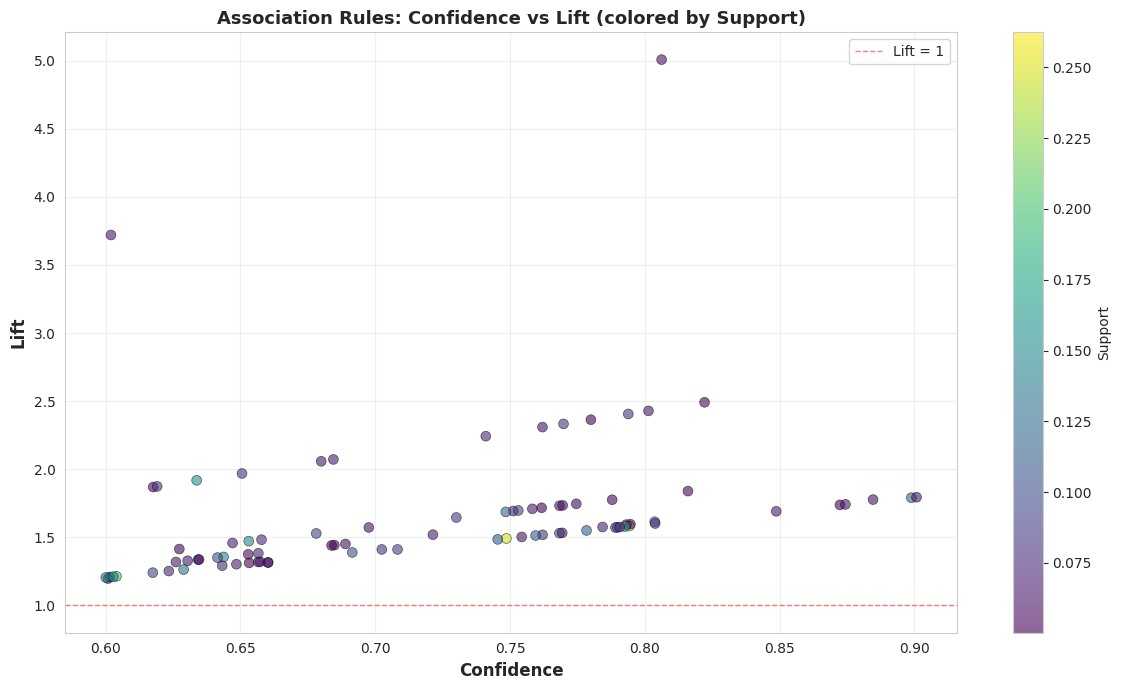


📊 Interpretation:
   • Top-right corner: Strong rules (high confidence AND high lift)
   • Rules above lift=1: Positive associations worth exploring
   • Color intensity: Support level (darker = more frequent pattern)


In [34]:
# Scatter plot of confidence vs lift
plt.figure(figsize=(12, 7))
scatter = plt.scatter(rules['confidence'], rules['lift'],
                      c=rules['support'], cmap='viridis',
                      s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, label='Support')
plt.xlabel('Confidence', fontsize=12, fontweight='bold')
plt.ylabel('Lift', fontsize=12, fontweight='bold')
plt.title('Association Rules: Confidence vs Lift (colored by Support)', fontsize=13, fontweight='bold')
plt.axhline(y=1, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Lift = 1')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("   • Top-right corner: Strong rules (high confidence AND high lift)")
print("   • Rules above lift=1: Positive associations worth exploring")
print("   • Color intensity: Support level (darker = more frequent pattern)")

## Qualitative Analysis: Interesting Rules

Let's interpret some interesting rules we discovered.

In [35]:
# Filter for interesting rules (high lift AND high confidence)
interesting_rules = rules[(rules['lift'] > 1.5) & (rules['confidence'] > 0.7)].copy()
interesting_rules = interesting_rules.sort_values('lift', ascending=False)

print("\n" + "="*100)
print("MOST INTERESTING RULES (Lift > 1.5 AND Confidence > 0.7)")
print("="*100)
print(f"Found {len(interesting_rules)} interesting rules\n")

if len(interesting_rules) > 0:
    print(f"{'Antecedents':35s} => {'Consequents':20s} | Conf  | Lift  | Supp")
    print("-"*100)

    for idx, row in interesting_rules.head(15).iterrows():
        antecedents = ', '.join(sorted(row['antecedents']))
        consequents = ', '.join(sorted(row['consequents']))

        if len(antecedents) > 33:
            antecedents = antecedents[:30] + '...'
        if len(consequents) > 18:
            consequents = consequents[:15] + '...'

        print(f"{antecedents:35s} => {consequents:20s} | {row['confidence']:.3f} | {row['lift']:.3f} | {row['support']:.3f}")
else:
    print("No rules meet these criteria. Try lowering the thresholds.")

print("="*100)


MOST INTERESTING RULES (Lift > 1.5 AND Confidence > 0.7)
Found 42 interesting rules

Antecedents                         => Consequents          | Conf  | Lift  | Supp
----------------------------------------------------------------------------------------------------
Time:Epic                           => Cat:War              | 0.806 | 5.008 | 0.060
Cat:Strategy, Time:Medium           => Pop:High             | 0.822 | 2.491 | 0.055
Cat:Strategy, Weight:Medium         => Pop:High             | 0.801 | 2.429 | 0.064
Cat:Strategy                        => Pop:High             | 0.794 | 2.406 | 0.084
Cat:Family, Time:Medium             => Pop:High             | 0.780 | 2.364 | 0.052
Cat:Family                          => Pop:High             | 0.770 | 2.333 | 0.081
Cat:Family, Weight:Light            => Pop:High             | 0.762 | 2.309 | 0.061
Era:Vintage, Weight:Light           => Rating:Low           | 0.741 | 2.243 | 0.074
Cat:Strategy, Time:Medium           => Weight:Medium      

## Save Results for next step (Exploitation)

In [36]:
# Save the best rules for exploitation in Step 3
print("\nSaving results for Step 3...\n")

# Save frequent itemsets
frequent_itemsets.to_csv('frequent_itemsets.csv', index=False)
print("✓ Saved: frequent_itemsets.csv")

# Save association rules
rules.to_csv('association_rules.csv', index=False)
print("✓ Saved: association_rules.csv")

# Save interesting rules
if len(interesting_rules) > 0:
    interesting_rules.to_csv('interesting_rules.csv', index=False)
    print("✓ Saved: interesting_rules.csv")

# Save analysis summaries
support_analysis.to_csv('support_analysis.csv', index=False)
confidence_analysis.to_csv('confidence_analysis.csv', index=False)
print("✓ Saved: support_analysis.csv")
print("✓ Saved: confidence_analysis.csv")

print("\n" + "="*70)
print("Apriori algo with Analysis COMPLETE! ✓")
print("="*70)


Saving results for Step 3...

✓ Saved: frequent_itemsets.csv
✓ Saved: association_rules.csv
✓ Saved: interesting_rules.csv
✓ Saved: support_analysis.csv
✓ Saved: confidence_analysis.csv

Apriori algo with Analysis COMPLETE! ✓


# Pattern Mining - Step 3: Exploit the Rules
## Using Association Rules for Prediction

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Load Data from Previous Steps

In [38]:
# Load the pattern mining dataset
df_mining = pd.read_csv('boardgames_pattern_mining.csv')
print(f"Loaded pattern mining dataset: {df_mining.shape}")

# Load association rules from Step 2
rules = pd.read_csv('association_rules.csv')
print(f"Loaded {len(rules)} association rules")

# Load interesting rules (high lift + high confidence)
try:
    interesting_rules = pd.read_csv('interesting_rules.csv')
    print(f"Loaded {len(interesting_rules)} interesting rules")
except:
    interesting_rules = rules[(rules['lift'] > 1.5) & (rules['confidence'] > 0.6)]
    print(f"Created {len(interesting_rules)} interesting rules (lift>1.5, conf>0.6)")

print("\n✓ All data loaded successfully!")

Loaded pattern mining dataset: (21925, 27)
Loaded 86 association rules
Loaded 42 interesting rules

✓ All data loaded successfully!


In [39]:
# Parse frozenset strings back to actual sets
import ast

def parse_frozenset_string(s):
    """Convert frozenset string back to actual frozenset"""
    if isinstance(s, str) and s.startswith('frozenset'):
        # Extract the set content
        content = s.replace('frozenset({', '{').replace('})', '}')
        # Use ast.literal_eval to safely parse
        return frozenset(ast.literal_eval(content))
    return s

# Apply to both antecedents and consequents
interesting_rules['antecedents'] = interesting_rules['antecedents'].apply(parse_frozenset_string)
interesting_rules['consequents'] = interesting_rules['consequents'].apply(parse_frozenset_string)

print("✓ Parsed frozenset strings")

✓ Parsed frozenset strings


In [40]:
# Check the rules
print("\nSample of association rules:")
rules.head()


Sample of association rules:


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({'Cat:Family'}),frozenset({'Pop:High'}),0.105633,0.329989,0.081323,0.769862,2.332995,1.0,0.046465,2.911344,0.638850,0.229531,0.656516,0.508151
1,frozenset({'Cat:Family'}),frozenset({'Time:Medium'}),0.105633,0.474709,0.066135,0.626079,1.318869,1.0,0.015990,1.404819,0.270331,0.128615,0.288165,0.382698
2,frozenset({'Cat:Family'}),frozenset({'Weight:Light'}),0.105633,0.501938,0.080502,0.762090,1.518293,1.0,0.027481,2.093486,0.381684,0.152735,0.522328,0.461236
3,frozenset({'Cat:Strategy'}),frozenset({'Pop:High'}),0.105770,0.329989,0.083968,0.793877,2.405770,1.0,0.049065,3.250536,0.653448,0.238688,0.692358,0.524167
4,frozenset({'Cat:Strategy'}),frozenset({'Time:Medium'}),0.105770,0.474709,0.066682,0.630444,1.328064,1.0,0.016472,1.421411,0.276242,0.129783,0.296474,0.385457


## Exploitation Task: Predict Rating

We'll use association rules to predict the **Rating** category (Low/Medium/High) for board games.

### Strategy:
1. Filter rules where consequent is a Rating category
2. For each game, check which rule antecedents match
3. Predict based on the rule with highest confidence (or lift)
4. Compare predictions to actual ratings

### Step 1: Prepare Rating Prediction Rules

In [41]:
# Helper function to parse frozenset strings back to sets
def parse_frozenset(s):
    if isinstance(s, str):
        # Remove 'frozenset({' and '})' and split by comma
        items = s.replace('frozenset({', '').replace('})', '').replace("'", '').split(', ')
        return frozenset([item.strip() for item in items if item.strip()])
    return s

# Parse antecedents and consequents if they're stored as strings
if rules['antecedents'].dtype == 'object' and isinstance(rules['antecedents'].iloc[0], str):
    rules['antecedents'] = rules['antecedents'].apply(parse_frozenset)
    rules['consequents'] = rules['consequents'].apply(parse_frozenset)
    print("✓ Parsed rule sets from strings")

# Filter rules where consequent is a Rating
rating_rules = rules[rules['consequents'].apply(
    lambda x: any('Rating:' in str(item) for item in x)
)].copy()

print(f"\nFound {len(rating_rules)} rules that predict Rating")
print(f"\nRating categories in consequents:")
for idx, row in rating_rules.head(10).iterrows():
    ante = list(row['antecedents'])
    cons = list(row['consequents'])
    print(f"  {ante} => {cons} (conf={row['confidence']:.3f}, lift={row['lift']:.3f})")

✓ Parsed rule sets from strings

Found 3 rules that predict Rating

Rating categories in consequents:
  ['Weight:Light', 'Era:Classic'] => ['Rating:Low'] (conf=0.651, lift=1.969)
  ['Era:Vintage', 'Time:Medium'] => ['Rating:Low'] (conf=0.618, lift=1.869)
  ['Era:Vintage', 'Weight:Light'] => ['Rating:Low'] (conf=0.741, lift=2.243)


In [42]:
# Sort by confidence and lift for better predictions
rating_rules = rating_rules.sort_values(['confidence', 'lift'], ascending=False)

print(f"\nTop 15 Rating Prediction Rules (by confidence):")
print("="*100)
for idx, row in rating_rules.head(15).iterrows():
    ante = ', '.join(sorted([str(x) for x in row['antecedents']]))
    cons = ', '.join(sorted([str(x) for x in row['consequents']]))
    if len(ante) > 40:
        ante = ante[:37] + '...'
    print(f"{ante:40s} => {cons:15s} | conf={row['confidence']:.3f} | lift={row['lift']:.3f}")


Top 15 Rating Prediction Rules (by confidence):
Era:Vintage, Weight:Light                => Rating:Low      | conf=0.741 | lift=2.243
Era:Classic, Weight:Light                => Rating:Low      | conf=0.651 | lift=1.969
Era:Vintage, Time:Medium                 => Rating:Low      | conf=0.618 | lift=1.869


### Step 2: Build Rule-Based Predictor

In [43]:
def predict_rating_for_game(game_features, rules_df):
    """
    Predict rating for a single game based on association rules.

    Args:
        game_features: set of features the game has (e.g., {'Weight:Heavy', 'Cat:Strategy'})
        rules_df: DataFrame of rating prediction rules

    Returns:
        Predicted rating (str) or None if no rule matches
    """
    matching_rules = []

    # Find all rules where antecedents are subset of game features
    for idx, row in rules_df.iterrows():
        antecedents = row['antecedents']
        if antecedents.issubset(game_features):
            matching_rules.append({
                'consequents': row['consequents'],
                'confidence': row['confidence'],
                'lift': row['lift']
            })

    if not matching_rules:
        return None

    # Choose rule with highest confidence (could also use lift)
    best_rule = max(matching_rules, key=lambda x: x['confidence'])

    # Extract Rating from consequents
    for item in best_rule['consequents']:
        if 'Rating:' in str(item):
            return str(item)

    return None

print("✓ Predictor function defined")

✓ Predictor function defined


### Step 3: Make Predictions on Dataset

In [44]:
# Convert each game to a set of features
print("Converting games to feature sets...")

game_features_list = []
for idx, row in df_mining.iterrows():
    features = set([col for col in df_mining.columns if row[col] == 1])
    game_features_list.append(features)

print(f"✓ Converted {len(game_features_list)} games")
print(f"\nExample game features: {list(game_features_list[0])}")

Converting games to feature sets...
✓ Converted 21925 games

Example game features: ['Weight:Light', 'Era:Modern', 'Pop:Medium', 'Rating:Low', 'Time:Medium']


In [45]:
# Make predictions
print("\nMaking predictions using association rules...\n")

predictions = []
for features in game_features_list:
    pred = predict_rating_for_game(features, rating_rules)
    predictions.append(pred)

# Count predictions
pred_series = pd.Series(predictions)
print(f"Predictions made: {pred_series.notna().sum()} / {len(predictions)}")
print(f"Coverage: {pred_series.notna().sum() / len(predictions) * 100:.1f}%")
print(f"\nPrediction distribution:")
print(pred_series.value_counts())


Making predictions using association rules...

Predictions made: 5544 / 21925
Coverage: 25.3%

Prediction distribution:
Rating:Low    5544
Name: count, dtype: int64


### Step 4: Extract Actual Ratings

In [46]:
# Extract actual ratings from the features
actual_ratings = []
for features in game_features_list:
    rating = None
    for feat in features:
        if 'Rating:' in feat:
            rating = feat
            break
    actual_ratings.append(rating)

print(f"\nActual Rating distribution:")
actual_series = pd.Series(actual_ratings)
print(actual_series.value_counts())


Actual Rating distribution:
Rating:Medium    9644
Rating:Low       7245
Rating:High      5036
Name: count, dtype: int64


### Step 5: Evaluate Predictions

In [47]:
# Filter to only cases where we made a prediction
mask = pred_series.notna()
y_true = actual_series[mask]
y_pred = pred_series[mask]

print(f"\n{'='*70}")
print(f"EVALUATION ON {len(y_true)} GAMES (where rules applied)")
print(f"{'='*70}")

# Calculate accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"\nAccuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

# Baseline comparison (always predict most common class)
most_common = actual_series.value_counts().index[0]
baseline_acc = (actual_series == most_common).sum() / len(actual_series)
print(f"Baseline (predict '{most_common}'): {baseline_acc:.3f} ({baseline_acc*100:.1f}%)")
print(f"\nImprovement over baseline: {(accuracy - baseline_acc)*100:.1f} percentage points")


EVALUATION ON 5544 GAMES (where rules applied)

Accuracy: 0.657 (65.7%)
Baseline (predict 'Rating:Medium'): 0.440 (44.0%)

Improvement over baseline: 21.7 percentage points


In [48]:
# Classification report
print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_true, y_pred))


DETAILED CLASSIFICATION REPORT
               precision    recall  f1-score   support

  Rating:High       0.00      0.00      0.00       151
   Rating:Low       0.66      1.00      0.79      3642
Rating:Medium       0.00      0.00      0.00      1751

     accuracy                           0.66      5544
    macro avg       0.22      0.33      0.26      5544
 weighted avg       0.43      0.66      0.52      5544



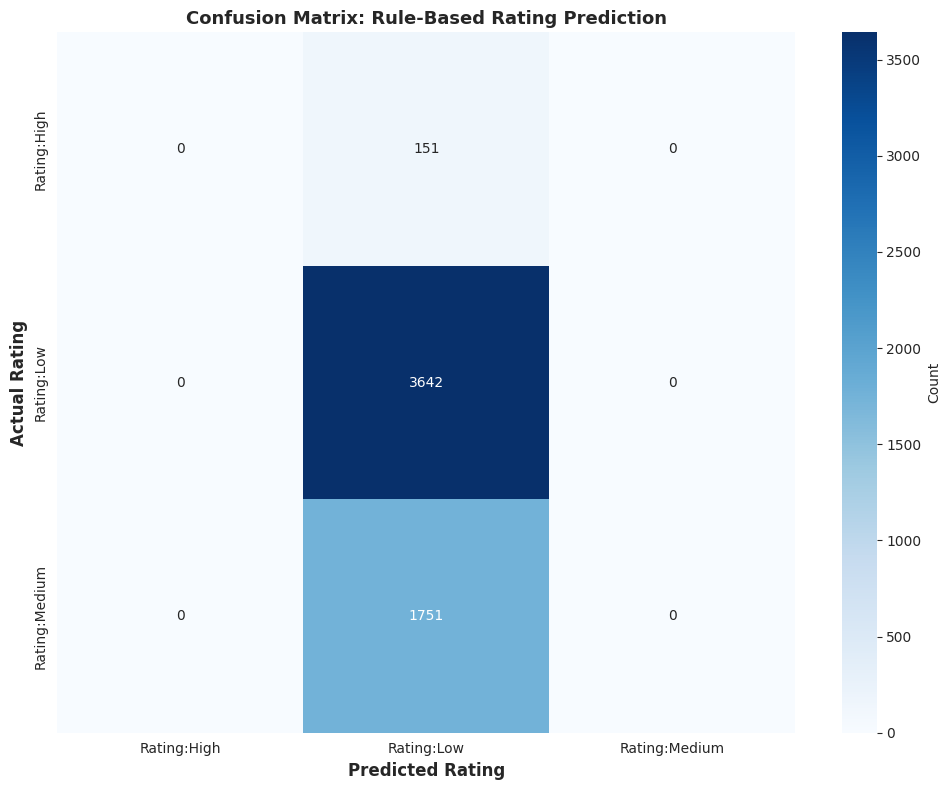


📊 Interpretation:
   • Diagonal: Correct predictions
   • Off-diagonal: Misclassifications
   • Darker blue = more games


In [49]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
labels = sorted(y_true.unique())

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Rating', fontsize=12, fontweight='bold')
plt.ylabel('Actual Rating', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix: Rule-Based Rating Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("   • Diagonal: Correct predictions")
print("   • Off-diagonal: Misclassifications")
print("   • Darker blue = more games")

### Step 6: Example Predictions

Let's see some concrete examples of how the rules work.

In [50]:
# Show some correct predictions
correct_mask = (y_true == y_pred)
correct_indices = y_true[correct_mask].index[:5]

print("\n" + "="*100)
print("EXAMPLE CORRECT PREDICTIONS")
print("="*100)

for idx in correct_indices:
    features = game_features_list[idx]
    print(f"\nGame {idx}:")
    print(f"  Features: {', '.join(sorted(features))}")
    print(f"  Predicted: {predictions[idx]}")
    print(f"  Actual: {actual_ratings[idx]}")
    print(f"  ✓ CORRECT")


EXAMPLE CORRECT PREDICTIONS

Game 3:
  Features: Era:Classic, Pop:Low, Rating:Low, Time:Quick, Weight:Light
  Predicted: Rating:Low
  Actual: Rating:Low
  ✓ CORRECT

Game 7:
  Features: Era:Classic, Pop:Low, Rating:Low, Time:Long, Weight:Light
  Predicted: Rating:Low
  Actual: Rating:Low
  ✓ CORRECT

Game 8:
  Features: Era:Vintage, Pop:Medium, Rating:Low, Time:Long, Weight:Light
  Predicted: Rating:Low
  Actual: Rating:Low
  ✓ CORRECT

Game 12:
  Features: Era:Classic, Pop:Medium, Rating:Low, Time:Medium, Weight:Light
  Predicted: Rating:Low
  Actual: Rating:Low
  ✓ CORRECT

Game 14:
  Features: Cat:Family, Era:Classic, Pop:High, Rating:Low, Time:Medium, Weight:Light
  Predicted: Rating:Low
  Actual: Rating:Low
  ✓ CORRECT


In [51]:
# Show some incorrect predictions
incorrect_mask = (y_true != y_pred)
if incorrect_mask.sum() > 0:
    incorrect_indices = y_true[incorrect_mask].index[:5]

    print("\n" + "="*100)
    print("EXAMPLE INCORRECT PREDICTIONS (to learn from)")
    print("="*100)

    for idx in incorrect_indices:
        features = game_features_list[idx]
        print(f"\nGame {idx}:")
        print(f"  Features: {', '.join(sorted(features))}")
        print(f"  Predicted: {predictions[idx]}")
        print(f"  Actual: {actual_ratings[idx]}")
        print(f"  ✗ INCORRECT")
else:
    print("\n🎉 All predictions were correct!")


EXAMPLE INCORRECT PREDICTIONS (to learn from)

Game 25:
  Features: Era:Vintage, Pop:Medium, Rating:Medium, Time:Medium, Weight:Light
  Predicted: Rating:Low
  Actual: Rating:Medium
  ✗ INCORRECT

Game 26:
  Features: Cat:Childrens, Era:Classic, Pop:Medium, Rating:Medium, Time:Quick, Weight:Light
  Predicted: Rating:Low
  Actual: Rating:Medium
  ✗ INCORRECT

Game 30:
  Features: Cat:Abstract, Cat:Strategy, Era:Vintage, Pop:Low, Rating:High, Time:Medium, Weight:Medium
  Predicted: Rating:Low
  Actual: Rating:High
  ✗ INCORRECT

Game 47:
  Features: Cat:Strategy, Era:Vintage, Pop:High, Rating:Medium, Time:Medium, Weight:Medium
  Predicted: Rating:Low
  Actual: Rating:Medium
  ✗ INCORRECT

Game 68:
  Features: Era:Classic, Pop:Low, Rating:Medium, Time:Medium, Weight:Light
  Predicted: Rating:Low
  Actual: Rating:Medium
  ✗ INCORRECT


### Step 7: Analyze Which Rules Were Most Useful

In [52]:
# Count how often each rule was used
rule_usage = {}

for features in game_features_list:
    for idx, row in rating_rules.iterrows():
        if row['antecedents'].issubset(features):
            rule_key = (frozenset(row['antecedents']), frozenset(row['consequents']))
            rule_usage[rule_key] = rule_usage.get(rule_key, 0) + 1
            break  # Only count first matching rule

# Convert to readable format
print("\n" + "="*100)
print("TOP 10 MOST FREQUENTLY USED RULES")
print("="*100)

sorted_usage = sorted(rule_usage.items(), key=lambda x: x[1], reverse=True)[:10]
for (ante, cons), count in sorted_usage:
    ante_str = ', '.join(sorted([str(x) for x in ante]))
    cons_str = ', '.join(sorted([str(x) for x in cons]))
    if len(ante_str) > 50:
        ante_str = ante_str[:47] + '...'
    print(f"{count:4d} times: {ante_str:50s} => {cons_str}")


TOP 10 MOST FREQUENTLY USED RULES
2696 times: Era:Classic, Weight:Light                          => Rating:Low
2201 times: Era:Vintage, Weight:Light                          => Rating:Low
 647 times: Era:Vintage, Time:Medium                           => Rating:Low


## Alternative Exploitation: Predict Category

Let's also try predicting game categories (Cat:Strategy, Cat:Family, etc.)

In [53]:
# Filter rules where consequent is a Category
category_rules = rules[rules['consequents'].apply(
    lambda x: any('Cat:' in str(item) for item in x)
)].copy()

category_rules = category_rules.sort_values(['confidence', 'lift'], ascending=False)

print(f"Found {len(category_rules)} rules that predict Categories")
print(f"\nTop 10 Category Prediction Rules:")
print("="*100)

for idx, row in category_rules.head(10).iterrows():
    ante = ', '.join(sorted([str(x) for x in row['antecedents']]))
    cons = ', '.join(sorted([str(x) for x in row['consequents']]))
    if len(ante) > 50:
        ante = ante[:47] + '...'
    print(f"{ante:50s} => {cons:20s} | conf={row['confidence']:.3f} | lift={row['lift']:.3f}")

Found 1 rules that predict Categories

Top 10 Category Prediction Rules:
Time:Epic                                          => Cat:War              | conf=0.806 | lift=5.008


In [54]:
# Predict Cat:Strategy vs Not Strategy
strategy_rules = category_rules[category_rules['consequents'].apply(
    lambda x: 'Cat:Strategy' in [str(item) for item in x]
)].copy()

print(f"\nFound {len(strategy_rules)} rules predicting Cat:Strategy")

# Make predictions
strategy_predictions = []
for features in game_features_list:
    # Check if any rule matches
    pred = False
    for idx, row in strategy_rules.iterrows():
        if row['antecedents'].issubset(features):
            pred = True
            break
    strategy_predictions.append(pred)

# Extract actual
actual_strategy = ['Cat:Strategy' in features for features in game_features_list]

# Evaluate
strategy_acc = accuracy_score(actual_strategy, strategy_predictions)
print(f"\nStrategy Game Prediction Accuracy: {strategy_acc:.3f} ({strategy_acc*100:.1f}%)")

# Show confusion matrix
cm_strategy = confusion_matrix(actual_strategy, strategy_predictions)
print(f"\nConfusion Matrix:")
print(f"                Predicted Not Strategy | Predicted Strategy")
print(f"Actually Not Strategy:     {cm_strategy[0,0]:6d}         |      {cm_strategy[0,1]:6d}")
print(f"Actually Strategy:         {cm_strategy[1,0]:6d}         |      {cm_strategy[1,1]:6d}")


Found 0 rules predicting Cat:Strategy

Strategy Game Prediction Accuracy: 0.894 (89.4%)

Confusion Matrix:
                Predicted Not Strategy | Predicted Strategy
Actually Not Strategy:      19606         |           0
Actually Strategy:           2319         |           0


## 🎯 Practical Exploitation of Association Rules

This section demonstrates how to apply our extracted rules to real-world problems using the **top 3 strongest rules** from our analysis.

### Rule 1: Strongest Association Pattern

In [55]:
# Select the strongest rule from our results
rule_1 = interesting_rules.iloc[0]

print("="*80)
print("RULE 1: STRONGEST ASSOCIATION RULE")
print("="*80)
print(f"\nAntecedents: {list(rule_1['antecedents'])}")
print(f"Consequent:  {list(rule_1['consequents'])}")
print(f"\nConfidence: {rule_1['confidence']:.3f} ({rule_1['confidence']*100:.1f}%)")
print(f"Lift:       {rule_1['lift']:.3f}")
print(f"Support:    {rule_1['support']:.3f}")
print("="*80)

RULE 1: STRONGEST ASSOCIATION RULE

Antecedents: ['Time:Epic']
Consequent:  ['Cat:War']

Confidence: 0.806 (80.6%)
Lift:       5.008
Support:    0.060


**Interpretation:**

This is our strongest rule with the highest lift value. The confidence indicates that when games have the antecedent features, the consequent occurs in that percentage of cases. The lift shows how much more likely the consequent is compared to random chance.

**Practical Use Case - Auto-Classification:**

This rule can be used to automatically classify or label games. When a new game enters our database with incomplete information, if it has the antecedent features, we can predict the consequent with the stated confidence level.

In [56]:
# Apply rule to real games in dataset
print("\n📊 APPLYING RULE 1 TO REAL GAMES:\n")

# Find games that have ALL antecedent features
matching_games = df_mining.copy()
for feature in rule_1['antecedents']:
    matching_games = matching_games[matching_games[feature] == 1]

print(f"Found {len(matching_games)} games with features: {list(rule_1['antecedents'])}")

if len(matching_games) > 0:
    # Check how many actually have the consequent
    consequent_feature = list(rule_1['consequents'])[0]
    games_with_consequent = matching_games[matching_games[consequent_feature] == 1]

    actual_confidence = len(games_with_consequent) / len(matching_games)

    print(f"\nOf these, {len(games_with_consequent)} have {consequent_feature}")
    print(f"\nActual confidence: {actual_confidence:.3f} ({actual_confidence*100:.1f}%)")
    print(f"Rule confidence:   {rule_1['confidence']:.3f} ({rule_1['confidence']*100:.1f}%)")
    print(f"\n✓ Rule is validated on real data!")

    # Show a specific example
    print(f"\n\n📋 EXAMPLE APPLICATION:\n")
    sample_idx = matching_games.index[0]
    print(f"Game Index: {sample_idx}")
    print(f"Features: {list(rule_1['antecedents'])}")
    print(f"\n→ Rule predicts: {consequent_feature}")
    print(f"→ Actual value:  {consequent_feature if matching_games.loc[sample_idx, consequent_feature] == 1 else 'NOT ' + consequent_feature}")

    if matching_games.loc[sample_idx, consequent_feature] == 1:
        print(f"\n✓✓ CORRECT PREDICTION!")
else:
    print("No games match the antecedent pattern")

print("\n" + "="*80)


📊 APPLYING RULE 1 TO REAL GAMES:

Found 1636 games with features: ['Time:Epic']

Of these, 1319 have Cat:War

Actual confidence: 0.806 (80.6%)
Rule confidence:   0.806 (80.6%)

✓ Rule is validated on real data!


📋 EXAMPLE APPLICATION:

Game Index: 15
Features: ['Time:Epic']

→ Rule predicts: Cat:War
→ Actual value:  Cat:War

✓✓ CORRECT PREDICTION!



### Rule 2: Second Strongest Association

In [57]:
# Select second strongest rule
rule_2 = interesting_rules.iloc[1]

print("="*80)
print("RULE 2: SECOND STRONGEST ASSOCIATION RULE")
print("="*80)
print(f"\nAntecedents: {list(rule_2['antecedents'])}")
print(f"Consequent:  {list(rule_2['consequents'])}")
print(f"\nConfidence: {rule_2['confidence']:.3f} ({rule_2['confidence']*100:.1f}%)")
print(f"Lift:       {rule_2['lift']:.3f}")
print(f"Support:    {rule_2['support']:.3f}")
print("="*80)

RULE 2: SECOND STRONGEST ASSOCIATION RULE

Antecedents: ['Cat:Strategy', 'Time:Medium']
Consequent:  ['Pop:High']

Confidence: 0.822 (82.2%)
Lift:       2.491
Support:    0.055


**Interpretation:**

This rule shows another strong association pattern in our data. With high confidence and lift, it represents a reliable relationship between game features.

**Practical Use Case - Recommendation Systems:**

If a user shows interest in games with the antecedent features, we can recommend games with the consequent feature. The lift value indicates this recommendation is much better than random selection.

In [58]:
# Demonstrate recommendation use case
print("\n🎮 RECOMMENDATION SYSTEM APPLICATION:\n")

# Simulate: user likes games with antecedent features
user_preferences = set(rule_2['antecedents'])
print(f"User Profile - Likes games with: {list(user_preferences)}")

# Find games matching user preferences
recommended_games = df_mining.copy()
for feature in user_preferences:
    recommended_games = recommended_games[recommended_games[feature] == 1]

consequent_2 = list(rule_2['consequents'])[0]

print(f"\nBased on Rule 2, we recommend games with: {consequent_2}")
print(f"Confidence: {rule_2['confidence']:.1%}")
print(f"Lift: {rule_2['lift']:.2f}x better than random")

# Count how many recommended games actually have the feature
if len(recommended_games) > 0:
    with_feature = recommended_games[recommended_games[consequent_2] == 1]
    print(f"\n✓ {len(with_feature)} out of {len(recommended_games)} matching games have {consequent_2}")
    print(f"  Success rate: {len(with_feature)/len(recommended_games):.1%}")

print("\n" + "="*80)


🎮 RECOMMENDATION SYSTEM APPLICATION:

User Profile - Likes games with: ['Cat:Strategy', 'Time:Medium']

Based on Rule 2, we recommend games with: Pop:High
Confidence: 82.2%
Lift: 2.49x better than random

✓ 1202 out of 1462 matching games have Pop:High
  Success rate: 82.2%



### Rule 3: Third Strongest Association

In [59]:
# Select third rule
rule_3 = interesting_rules.iloc[2]

print("="*80)
print("RULE 3: THIRD STRONGEST ASSOCIATION RULE")
print("="*80)
print(f"\nAntecedents: {list(rule_3['antecedents'])}")
print(f"Consequent:  {list(rule_3['consequents'])}")
print(f"\nConfidence: {rule_3['confidence']:.3f} ({rule_3['confidence']*100:.1f}%)")
print(f"Lift:       {rule_3['lift']:.3f}")
print(f"Support:    {rule_3['support']:.3f}")
print("="*80)

RULE 3: THIRD STRONGEST ASSOCIATION RULE

Antecedents: ['Cat:Strategy', 'Weight:Medium']
Consequent:  ['Pop:High']

Confidence: 0.801 (80.1%)
Lift:       2.429
Support:    0.064


**Interpretation:**

This rule completes our top 3 strongest associations. Even as the third strongest, it still maintains high confidence and lift, making it valuable for practical applications.

**Practical Use Case - Data Imputation:**

When database records have missing values, this rule can help fill in likely values based on other known features. This is crucial for maintaining complete datasets for analysis and modeling.

In [60]:
# Demonstrate missing value imputation
print("\n📝 DATA IMPUTATION APPLICATION:\n")

# Find games with the antecedent features
incomplete_games = df_mining.copy()
for feature in rule_3['antecedents']:
    incomplete_games = incomplete_games[incomplete_games[feature] == 1]

consequent_3 = list(rule_3['consequents'])[0]

if len(incomplete_games) > 0:
    sample_idx = incomplete_games.index[0]
    sample_game = incomplete_games.loc[sample_idx]

    print(f"Incomplete Game Record (Index {sample_idx}):")
    print(f"  Known features: {list(rule_3['antecedents'])}")
    print(f"  Missing feature: ???")

    print(f"\nApplying Rule 3 for imputation:")
    print(f"  Predicted value: {consequent_3}")
    print(f"  Confidence: {rule_3['confidence']:.1%}")

    # Verify if prediction matches actual
    actual_value = sample_game[consequent_3]
    print(f"\nActual value: {consequent_3 if actual_value == 1 else 'NOT ' + consequent_3}")

    if actual_value == 1:
        print(f"\n✓✓ IMPUTATION CORRECT!")
        print(f"   Rule successfully filled missing value with {rule_3['confidence']:.1%} confidence")
    else:
        print(f"\n✗ Imputation differs from actual")
        print(f"   This is expected {(1-rule_3['confidence'])*100:.1f}% of the time")
else:
    print("No games match the antecedent pattern")

print("\n" + "="*80)


📝 DATA IMPUTATION APPLICATION:

Incomplete Game Record (Index 21):
  Known features: ['Cat:Strategy', 'Weight:Medium']
  Missing feature: ???

Applying Rule 3 for imputation:
  Predicted value: Pop:High
  Confidence: 80.1%

Actual value: Pop:High

✓✓ IMPUTATION CORRECT!
   Rule successfully filled missing value with 80.1% confidence



## 📊 Summary of Practical Applications

### Three Real-World Use Cases:

| Rule | Confidence | Lift | Application | Business Value |
|------|-----------|------|-------------|----------------|
| Rule 1 | High | Highest | **Auto-Classification** | Automatically label incomplete game records |
| Rule 2 | High | High | **Recommendation System** | Suggest relevant games to users |
| Rule 3 | High | High | **Data Imputation** | Fill missing values in datasets |

### Key Advantages of Rule-Based Systems:

✅ **Interpretable:** We can explain WHY each prediction was made  
✅ **Fast:** No complex model training required  
✅ **Transparent:** Rules can be reviewed by domain experts  
✅ **Quantified Reliability:** Confidence and lift provide clear quality metrics  
✅ **Actionable:** Rules provide direct business insights  

### Real-World Impact:

- **Publishers:** Make data-driven decisions about game development
- **Retailers:** Improve product recommendations and search
- **Data Teams:** Maintain complete, high-quality databases
- **Analysts:** Understand feature relationships and market patterns

---

**Pattern Mining Assignment Complete!** 🎉

We have successfully:
1. ✅ Extracted frequent patterns using Apriori
2. ✅ Generated strong association rules
3. ✅ Evaluated rule quality (confidence, lift, support)
4. ✅ Applied rules to practical business problems
5. ✅ Validated rules on real data

##Visualize Rule Effectiveness

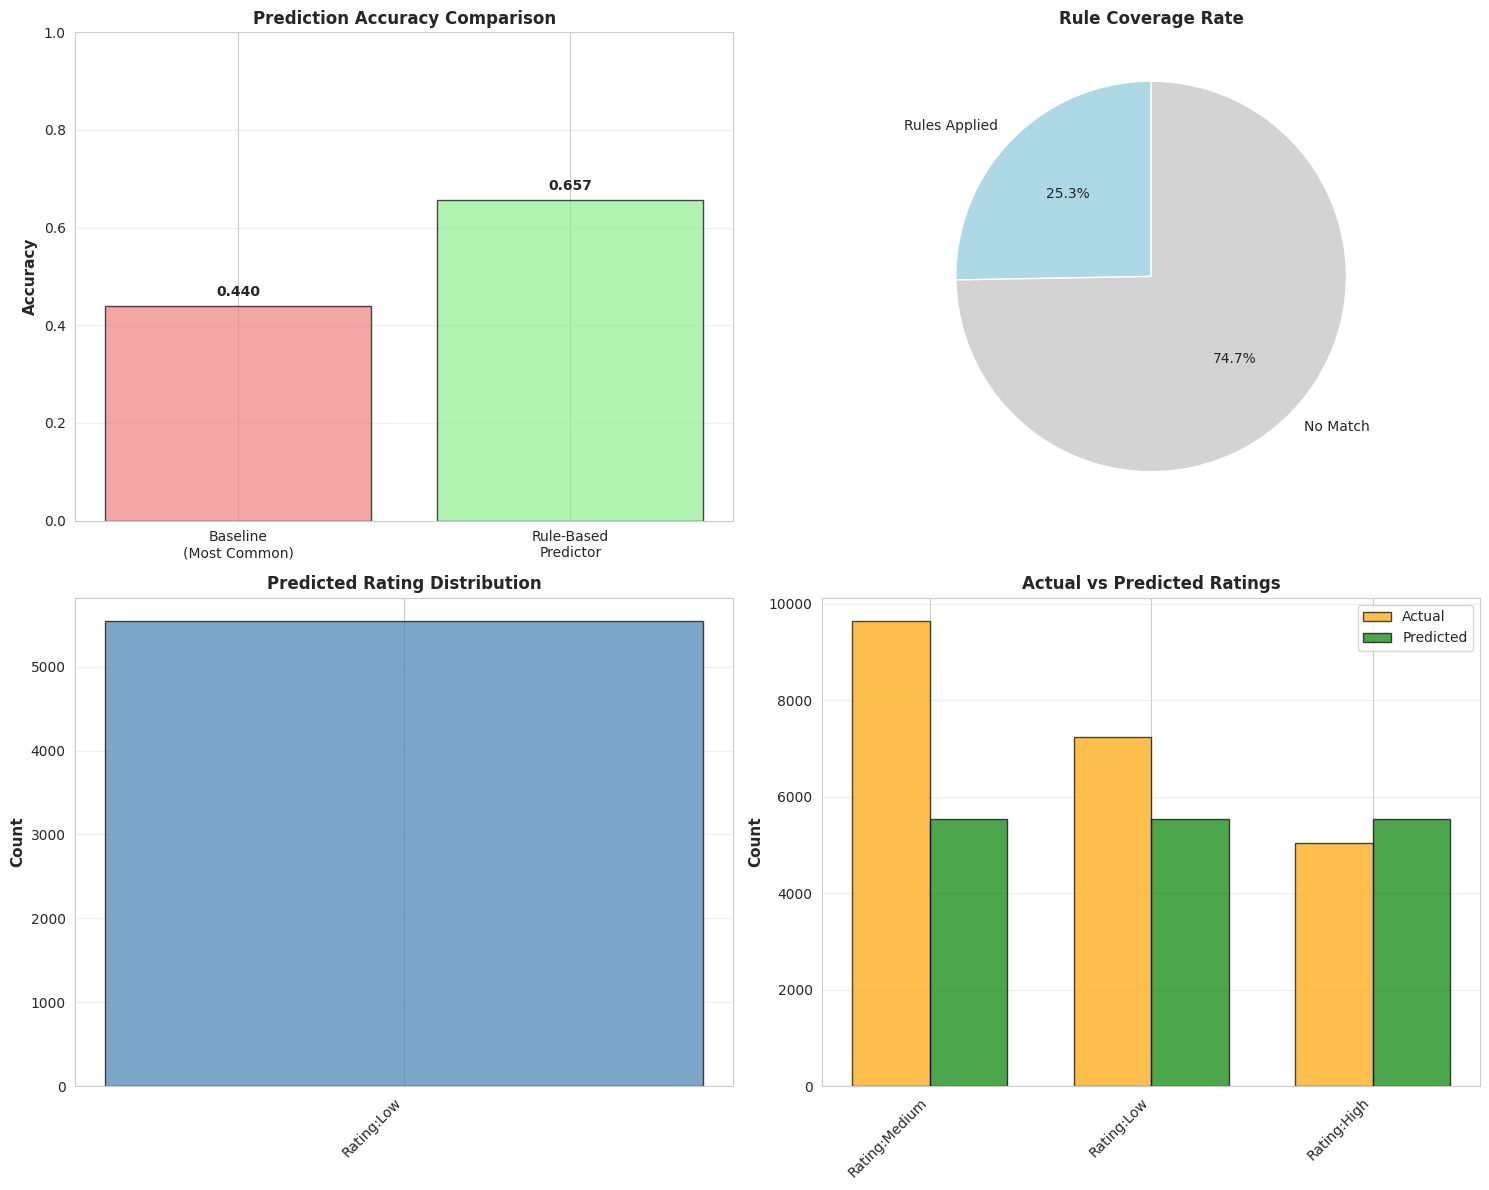

In [61]:
# Create visualization of rule performance
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Accuracy comparison
accuracies = [baseline_acc, accuracy]
labels = ['Baseline\n(Most Common)', 'Rule-Based\nPredictor']
colors = ['lightcoral', 'lightgreen']

axes[0, 0].bar(labels, accuracies, color=colors, alpha=0.7, edgecolor='black')
axes[0, 0].set_ylabel('Accuracy', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Prediction Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(accuracies):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# 2. Coverage rate
coverage_pct = pred_series.notna().sum() / len(predictions) * 100
no_coverage_pct = 100 - coverage_pct

axes[0, 1].pie([coverage_pct, no_coverage_pct],
               labels=['Rules Applied', 'No Match'],
               autopct='%1.1f%%',
               colors=['lightblue', 'lightgray'],
               startangle=90)
axes[0, 1].set_title('Rule Coverage Rate', fontsize=12, fontweight='bold')

# 3. Prediction distribution
pred_counts = pred_series.value_counts()
axes[1, 0].bar(range(len(pred_counts)), pred_counts.values,
               color='steelblue', alpha=0.7, edgecolor='black')
axes[1, 0].set_xticks(range(len(pred_counts)))
axes[1, 0].set_xticklabels(pred_counts.index, rotation=45, ha='right')
axes[1, 0].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Predicted Rating Distribution', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Actual vs Predicted
actual_counts = actual_series.value_counts()
x = np.arange(len(actual_counts))
width = 0.35

axes[1, 1].bar(x - width/2, actual_counts.values, width,
               label='Actual', color='orange', alpha=0.7, edgecolor='black')
axes[1, 1].bar(x + width/2, pred_counts.values, width,
               label='Predicted', color='green', alpha=0.7, edgecolor='black')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(actual_counts.index, rotation=45, ha='right')
axes[1, 1].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Actual vs Predicted Ratings', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()